In [1]:
from pathlib import Path
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, concatenate_datasets, Dataset
from tokenizers import Tokenizer
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


wikimatrix = load_dataset("sentence-transformers/parallel-sentences-wikimatrix", "en-zh")["train"]
opensubtitles = load_dataset("sentence-transformers/parallel-sentences-opensubtitles", "en-zh_cn")["train"]
talks = load_dataset("sentence-transformers/parallel-sentences-talks", "en-zh-cn")["train"]
tatoeba = load_dataset("sentence-transformers/parallel-sentences-tatoeba", "en-zh")["train"]
# ccmatrix = load_dataset("sentence-transformers/parallel-sentences-ccmatrix", "en-zh")["train"]

raw_dataset = concatenate_datasets([wikimatrix, opensubtitles, talks, tatoeba])

Using the latest cached version of the dataset since sentence-transformers/parallel-sentences-wikimatrix couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'en-zh' at C:\Users\karis\.cache\huggingface\datasets\sentence-transformers___parallel-sentences-wikimatrix\en-zh\0.0.0\74a4cb15422cdd0c3aacc93593b6cb96a9b9b3a9 (last modified on Thu Apr 17 22:12:38 2025).
Using the latest cached version of the dataset since sentence-transformers/parallel-sentences-opensubtitles couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'en-zh_cn' at C:\Users\karis\.cache\huggingface\datasets\sentence-transformers___parallel-sentences-opensubtitles\en-zh_cn\0.0.0\d86a387587ab6f2fd9ec7453b2765cec68111c87 (last modified on Thu Apr 17 21:50:45 2025).
Using the latest cached version of the dataset since sentence-transformers/parallel-sentences-talks couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'e

In [2]:
def dataset_processing(dataset: Dataset, squence_length: int = 512):
    def chinese_rule(code: int):
        return code < 128 or 0x4E00 <= code <= 0x9FFF or 0x3000 <= code <= 0x303F or 0xFF01 <= code <= 0xFF5E

    def english_rule(code: int):
        return code < 128 or 0x3000 <= code <= 0x303F or 0xFF01 <= code <= 0xFF5E

    squence_length = squence_length - 2

    en_list: list[str] = []
    zh_list: list[str] = []
    for data in tqdm(dataset, desc="pre-processing"):
        en = data["english"]
        zh = data["non_english"]
        if len(en) > squence_length or len(zh) > squence_length:
            continue
        if all([english_rule(ord(c)) for c in en]) and all([chinese_rule(ord(c)) for c in zh]):
            en_list.append(en)
            zh_list.append(zh)
    print(f"训练句对长度: {len(en_list)}")
    return en_list, zh_list
    
en_list, zh_list = dataset_processing(raw_dataset)

en_tokenizer_path = Path("en_tokenizer.json")
zh_tokenizer_path = Path("zh_tokenizer.json")

if en_tokenizer_path.exists() and zh_tokenizer_path.exists():
    en_tokenizer = Tokenizer.from_file(en_tokenizer_path.as_posix())
    zh_tokenizer = Tokenizer.from_file(zh_tokenizer_path.as_posix())
else:

    from tokenizers import models, trainers, pre_tokenizers

    en_vocab_size = 25000
    zh_vocab_size = 25000
    min_frequency = 2

    special_tokens = ["[PAD]", "[UNK]", "[SOS]", "[EOS]"]
    continuing_subword_prefix = "##"
    # 英文分词器
    en_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    en_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    en_trainer = trainers.WordPieceTrainer(
        vocab_size=en_vocab_size,
        min_frequency=min_frequency,
        special_tokens=special_tokens + [".", ",", "!", "?", ";", ":"],
        continuing_subword_prefix=continuing_subword_prefix,
    )
    en_tokenizer.train_from_iterator(en_list, trainer=en_trainer)
    # 中文分词器
    zh_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    zh_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
    zh_trainer = trainers.WordPieceTrainer(
        vocab_size=zh_vocab_size,
        min_frequency=min_frequency,
        special_tokens=special_tokens + [".", ",", "!", "?", ";", ":"] + [chr(i) for i in range(0x3000, 0x303F)],
        continuing_subword_prefix=continuing_subword_prefix,
    )
    zh_tokenizer.train_from_iterator(zh_list, trainer=zh_trainer)
    # 处理文本编码
    en_tokenizer.save(en_tokenizer_path.as_posix())
    zh_tokenizer.save(zh_tokenizer_path.as_posix())

PAD, UNK, SOS, EOS = 0, 1, 2, 3
assert en_tokenizer.token_to_id("[PAD]") == zh_tokenizer.token_to_id("[PAD]") == PAD
assert en_tokenizer.token_to_id("[UNK]") == zh_tokenizer.token_to_id("[UNK]") == UNK
assert en_tokenizer.token_to_id("[SOS]") == zh_tokenizer.token_to_id("[SOS]") == SOS
assert en_tokenizer.token_to_id("[EOS]") == zh_tokenizer.token_to_id("[EOS]") == EOS

en_dataset = [torch.tensor(en_tokenizer.encode(text).ids + [EOS], device=DEVICE) for text in tqdm(en_list, desc="build en")]
zh_dataset = [torch.tensor([SOS] + zh_tokenizer.encode(text).ids + [EOS], device=DEVICE) for text in tqdm(zh_list, desc="build zh")]
dataset = [(en, zh) for en, zh in zip(en_dataset, zh_dataset)]


def collate_fn(batch):
    en_batch, zh_batch = zip(*batch)
    en_batch = pad_sequence(en_batch, batch_first=True)
    zh_batch = pad_sequence(zh_batch, batch_first=True)
    return en_batch, zh_batch


train_loader = DataLoader(dataset, batch_size=24, shuffle=True, collate_fn=collate_fn)

pre-processing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 874236/874236 [00:27<00:00, 31580.16it/s]


训练句对长度: 794938


build zh: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 794938/794938 [01:07<00:00, 11762.44it/s]


In [3]:
class TransformerEDM(torch.nn.Module):
    def __init__(
        self,
        enc_vs: int,
        dec_vs: int,
        emb_size: int,
        head_size: int,
        n_block: int,
        sequence_length: int,
    ):
        super().__init__()
        # 编码器
        self.enc_token_emb = torch.nn.Embedding(enc_vs, emb_size)
        self.enc_position_emb = torch.nn.Embedding(sequence_length, emb_size)
        # 解码器
        self.dec_token_emb = torch.nn.Embedding(dec_vs, emb_size)
        self.dec_position_emb = torch.nn.Embedding(sequence_length, emb_size)
        self.dec_fc_out = torch.nn.Linear(emb_size, dec_vs)
        assert emb_size % head_size == 0
        nhead = emb_size // head_size
        self.transformer = torch.nn.Transformer(
            num_encoder_layers=n_block,
            num_decoder_layers=n_block,
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=emb_size * 4,
            activation="gelu",
            batch_first=True,
        )
        self.position: torch.Tensor
        self.register_buffer("position", torch.arange(0, sequence_length, dtype=torch.long))
        self.mask: torch.Tensor
        self.register_buffer("mask", torch.triu(torch.ones(sequence_length, sequence_length, dtype=torch.bool)))

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor):
        T_src = inputs.size(-1)
        T_tgt = targets.size(-1)
        encoding = self.enc_token_emb(inputs) + self.enc_position_emb(self.position[:T_src])
        decoding = self.dec_token_emb(targets) + self.dec_position_emb(self.position[:T_tgt])
        logits = self.transformer.forward(
            encoding,
            decoding,
            tgt_mask=self.mask[:T_tgt, :T_tgt],
            src_key_padding_mask=(inputs == PAD),
            tgt_key_padding_mask=(targets == PAD),
        )
        return self.dec_fc_out(logits)


def train(model: torch.nn.Module, loader: DataLoader, num_epochs=1, lr=0.001, save_path: Path | None = None):
    print("模型参数：", sum(p.numel() for p in model.parameters() if p.requires_grad))
    model.train()
    criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    lossi = []
    for epoch in range(num_epochs):
        for i, (inputs, targets) in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
            outputs = model.forward(inputs, targets)
            loss = criterion(outputs.transpose(-2, -1), targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lossi.append(loss.item())
        print(f"Current Loss {lossi[-1]:.4f}")
        if save_path is not None:
            torch.save(model, save_path / f"model{epoch+1}.pth")
    return lossi


lossi = []

In [4]:
model = TransformerEDM(
    enc_vs=en_tokenizer.get_vocab_size(),
    dec_vs=zh_tokenizer.get_vocab_size(),
    emb_size=256,
    head_size=32,
    n_block=6,
    sequence_length=512,
)

model.to(DEVICE)
# 重复执行
lossi = train(model, train_loader, num_epochs=1, lr=0.001)

模型参数： 30547368


Epoch 1/1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33123/33123 [30:37<00:00, 18.03it/s]

Current Loss 7.1220


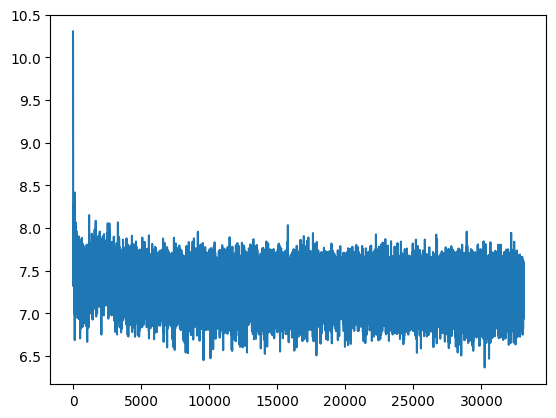

In [5]:
plt.plot(torch.tensor(lossi))
plt.show()

In [6]:
torch.cuda.empty_cache()

In [7]:
class FeedForward(torch.nn.Module):

    def __init__(self, emb_size: int):
        super().__init__()
        self.lm1 = torch.nn.Linear(emb_size, 4 * emb_size)
        self.lm2 = torch.nn.Linear(4 * emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)

    def forward(self, x: torch.Tensor):
        out = torch.nn.functional.gelu(self.lm1(x))
        out = self.dp(self.lm2(out))
        return out


class SelfAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        self.head_size = head_size
        super().__init__()
        self.key = torch.nn.Linear(emb_size, head_size, bias=False)
        self.query = torch.nn.Linear(emb_size, head_size, bias=False)
        self.value = torch.nn.Linear(emb_size, head_size, bias=False)

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None):
        key = self.key(x)
        query = self.query(x)
        value = self.value(x)
        scores = query @ key.transpose(-2, -1) / self.head_size**0.5
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        w_att = torch.softmax(scores, dim=-1)
        return w_att @ value


class SelfMultiHeadAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        assert emb_size % head_size == 0
        super().__init__()
        # 计算单头注意力的个数
        n_head = emb_size // head_size
        self.heads = torch.nn.ModuleList(SelfAttention(emb_size, head_size) for _ in range(n_head))
        self.proj = torch.nn.Linear(emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        mha = torch.cat([h(x, mask) for h in self.heads], dim=-1)
        mha = self.dp(self.proj(mha))
        return mha


class CrossAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        self.head_size = head_size
        super().__init__()
        self.key = torch.nn.Linear(emb_size, head_size, bias=False)
        self.query = torch.nn.Linear(emb_size, head_size, bias=False)
        self.value = torch.nn.Linear(emb_size, head_size, bias=False)

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        key = self.key(y)
        query = self.query(x)
        value = self.value(y)
        scores = query @ key.transpose(-2, -1) / self.head_size**0.5
        w_att = torch.softmax(scores, dim=-1)
        return w_att @ value


class CrossMultiHeadAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        assert emb_size % head_size == 0
        super().__init__()
        # 计算单头注意力的个数
        n_head = emb_size // head_size
        self.heads = torch.nn.ModuleList(CrossAttention(emb_size, head_size) for _ in range(n_head))
        self.proj = torch.nn.Linear(emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        cross_mha = torch.cat([h(x, y) for h in self.heads], dim=-1)
        mha = self.dp(self.proj(cross_mha))
        return mha


class EncoderBlock(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        super().__init__()
        self.mha_ln = torch.nn.LayerNorm(emb_size)
        self.mha = SelfMultiHeadAttention(emb_size, head_size)
        self.ff_ln = torch.nn.LayerNorm(emb_size)
        self.ff = FeedForward(emb_size)

    def forward(self, x: torch.Tensor):
        x = x + self.mha(self.mha_ln(x), None)
        x = x + self.ff(self.ff_ln(x))
        return x


class DecoderBlock(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        super().__init__()
        self.mha_ln = torch.nn.LayerNorm(emb_size)
        self.mha = SelfMultiHeadAttention(emb_size, head_size)
        self.cross_mha_ln = torch.nn.LayerNorm(emb_size)
        self.cross_mha = CrossMultiHeadAttention(emb_size, head_size)
        self.ff_ln = torch.nn.LayerNorm(emb_size)
        self.ff = FeedForward(emb_size)

    def forward(self, x: torch.Tensor, y: torch.Tensor, mask: torch.Tensor):
        x = self.mha(self.mha_ln(x), mask)
        x = x + self.cross_mha(self.cross_mha_ln(x), y)
        x = x + self.ff(self.ff_ln(x))
        return x


class TransformerEDM(torch.nn.Module):
    def __init__(
        self,
        enc_vs: int,
        dec_vs: int,
        emb_size: int,
        head_size: int,
        n_block: int,
        sequence_length: int,
    ):
        super().__init__()
        # 编码器
        self.enc_token_emb = torch.nn.Embedding(enc_vs, emb_size)
        self.enc_position_emb = torch.nn.Embedding(sequence_length, emb_size)
        self.enc_blocks = torch.nn.ModuleList()
        # 解码器
        self.dec_token_emb = torch.nn.Embedding(dec_vs, emb_size)
        self.dec_position_emb = torch.nn.Embedding(sequence_length, emb_size)
        self.dec_blocks = torch.nn.ModuleList()
        self.blocks = [
            (
                EncoderBlock(emb_size, head_size),
                DecoderBlock(emb_size, head_size),
            )
            for _ in range(n_block)
        ]
        for enc_block, dec_block in self.blocks:
            self.enc_blocks.append(enc_block)
            self.dec_blocks.append(dec_block)

        self.dec_lm = torch.nn.Linear(emb_size, dec_vs)
        self.dec_ln = torch.nn.LayerNorm(emb_size)
        # 下面是其他属性
        self.mask: torch.Tensor
        self.register_buffer("mask", torch.tril(torch.ones(sequence_length, sequence_length)))
        self.position: torch.Tensor
        self.register_buffer("position", torch.arange(0, sequence_length, dtype=torch.long))

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        Tx = x.size(-1)
        Ty = y.size(-1)
        inputs = self.enc_token_emb(x) + self.enc_position_emb(self.position[:Tx])
        outputs = self.dec_token_emb(y) + self.dec_position_emb(self.position[:Ty])
        mask = self.mask[:Ty, :Ty]
        for enc_block, dec_block in self.blocks:
            inputs = enc_block(inputs)
            outputs = dec_block(outputs, inputs, mask)

        out = self.dec_lm(self.dec_ln(outputs))
        return out

In [8]:
model = TransformerEDM(
    enc_vs=en_tokenizer.get_vocab_size(),
    dec_vs=zh_tokenizer.get_vocab_size(),
    emb_size=256,
    head_size=32,
    n_block=6,
    sequence_length=512,
)

model.to(DEVICE)
# 重复执行
lossi = train(model, train_loader, num_epochs=1, lr=0.001)

模型参数： 30533032


Epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33123/33123 [2:47:24<00:00,  3.30it/s]

Current Loss 6.6819


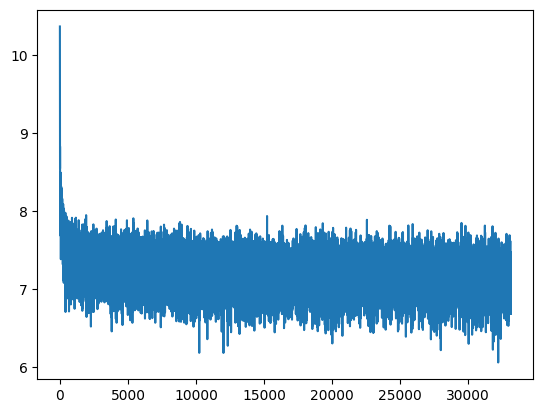

In [9]:
plt.plot(torch.tensor(lossi))
plt.show()

In [10]:
torch.cuda.empty_cache()

In [11]:
class AttentionEDM(torch.nn.Module):
    def __init__(
        self,
        enc_vs: int,
        dec_vs: int,
        emb_size: int,
        hidden_size: int,
        num_layers: int,
        dropout: float = 0,
    ):
        super().__init__()
        self.enc_embedding = torch.nn.Embedding(enc_vs, emb_size)
        self.enc_lstm = torch.nn.LSTM(emb_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.dec_embedding = torch.nn.Embedding(dec_vs, hidden_size)
        self.dec_lstm = torch.nn.LSTM(hidden_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.lm = torch.nn.Linear(hidden_size, dec_vs)

    def forward(self, source: torch.Tensor, target: torch.Tensor, teacher_forcing_ratio: float = 0.5):
        embed_source: torch.Tensor = self.enc_embedding(source)
        encoder_hiddens = []
        state = None
        for x in embed_source.unbind(1):
            _, (hidden, cell) = self.enc_lstm(x.unsqueeze(1), state)
            state = (hidden, cell)
            encoder_hiddens.append(hidden)
        encoded = torch.stack(encoder_hiddens, dim=-2)
        encoded_trans = torch.transpose(encoded, -2, -1)
        sqrtT: float = encoded_trans.size(-1) ** 0.5
        outputs = []
        x = target[:, 0].unsqueeze(-1)
        for target_t in target.unbind(1):
            embed = self.dec_embedding(x)
            scores = embed.unsqueeze(0) @ encoded_trans
            scores = torch.softmax(scores / sqrtT, dim=-1)
            hidden = scores @ encoded
            dec_output, (hidden, cell) = self.dec_lstm(embed, (hidden.squeeze(-2), cell))
            output = self.lm(dec_output)
            outputs.append(output)
            if teacher_forcing_ratio > 0 and torch.rand(1).item() < teacher_forcing_ratio:
                x = target_t.unsqueeze(1)
            else:
                x = output.argmax(dim=-1)
        return torch.cat(outputs, 1)

In [12]:
model_rnn = AttentionEDM(
    enc_vs=en_tokenizer.get_vocab_size(),
    dec_vs=zh_tokenizer.get_vocab_size(),
    emb_size=256,
    hidden_size=256,
    num_layers=3,
)

model_rnn.to(DEVICE)
# 重复执行
lossi = train(model_rnn, train_loader, num_epochs=1, lr=0.001)

模型参数： 22383016


Epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33123/33123 [1:48:08<00:00,  5.10it/s]

Current Loss 5.7867


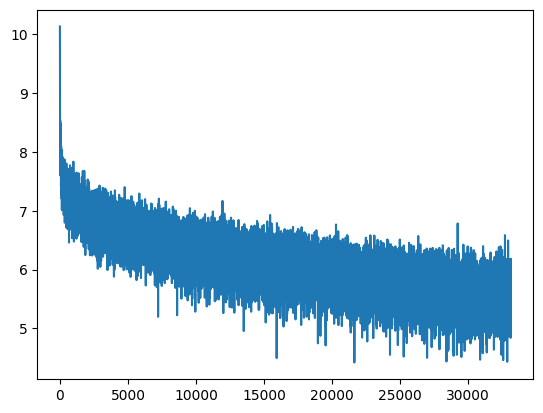

In [13]:
plt.plot(torch.tensor(lossi))
plt.show()

In [ ]:
class Translator:
    def __init__(self, source_tokenizer: Tokenizer, target_tokenizer: Tokenizer, model: TransformerEDM):
        self.source_tokenizer = source_tokenizer
        self.target_tokenizer = target_tokenizer
        self.pad_ind = self.target_tokenizer.token_to_id("[PAD]")
        self.unk_ind = self.target_tokenizer.token_to_id("[UNK]")
        self.sos_ind = self.target_tokenizer.token_to_id("[SOS]")
        self.eos_ind = self.target_tokenizer.token_to_id("[EOS]")
        self.model = model
        self.sequence_length = model.position.size(0)

    @torch.no_grad()
    def generate(self, source: str, device=DEVICE) -> str:
        source_ids = self.source_tokenizer.encode(source).ids
        source_ids.append(self.eos_ind)
        inputs = torch.tensor(source_ids, dtype=torch.long, device=device).unsqueeze(0)
        targets = torch.tensor([self.sos_ind], dtype=torch.long, device=device).unsqueeze(0)
        for i in range(self.sequence_length):
            output = self.model(inputs, targets)
            next_token = output[:, -1, :].argmax(dim=-1, keepdim=True)
            targets = torch.cat([targets, next_token], dim=-1)
        target_ids = targets.squeeze(0).tolist()
        return self.target_tokenizer.decode(target_ids, skip_special_tokens=False)

In [ ]:
translator = Translator(en_tokenizer, zh_tokenizer, model=model)

In [ ]:
print(translator.generate("I love You"))